`conda activate r_env_standr`

Idea taken from https://doi.org/10.1038/s41588-022-01243-4 <br>
Code obtained from https://github.com/elo073/5loclung/blob/main/Explained%20Variability/

In [ ]:
suppressPackageStartupMessages({
    library(Seurat)
    library(dplyr)
    library(here)
    library(tibble)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(reticulate)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})


source(here("scripts/style.R")) 
source(here("scripts/Barplot.LFLMM.R")) 
source(here("scripts/LFLMM.LMMBF.R")) 
source(here("scripts/functions.R")) 

ggplot2::theme_set(theme_min())

In [ ]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds')
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <- AddMetaData(dmg, readRDS('../../data/dmg_atlas_final_annotation.rds'))

In [ ]:
table(dmg$lvl_1)


   Immune Macroglia Malignant  Neuronal  Vascular 
    65390     42383    274318      7423      8280 

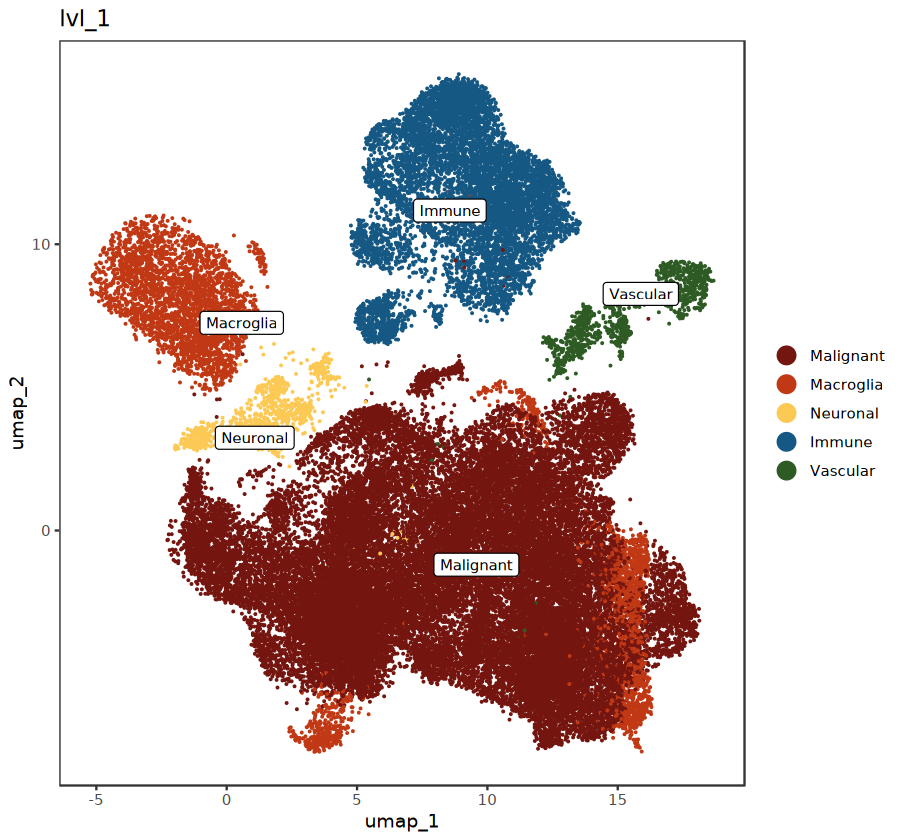

In [ ]:
dmg$lvl_1 <- factor(dmg$lvl_1, levels = c('Malignant', 'Macroglia','Neuronal','Immune','Vascular'))

colors_lvl_1 <- c('#74150f', '#c13814', '#fdc955', '#165884', '#2e5b24')

options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(subset(dmg, cells = sample(Cells(dmg), 50000)),
             color.panel = colors_lvl_1,
             reduction.use = "umap", var = "lvl_1", 
             do.label = T, labels.size = 3, size = 0.5)

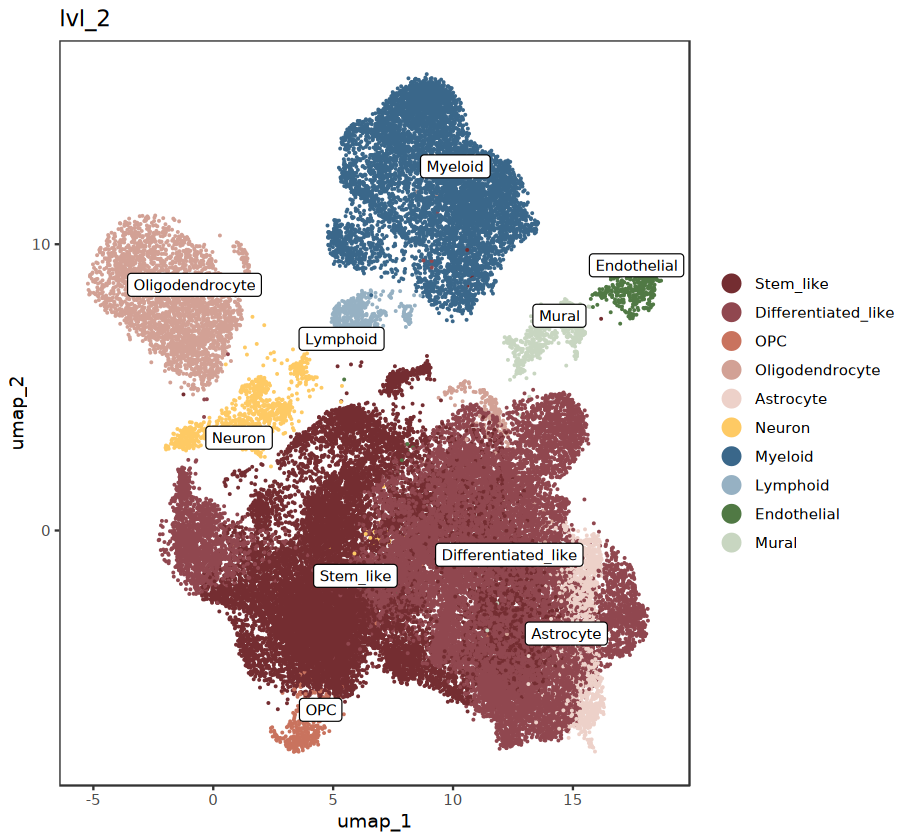

In [ ]:
dmg$lvl_2 <- factor(dmg$lvl_2, levels = c('Stem_like','Differentiated_like',
                                          'OPC','Oligodendrocyte','Astrocyte',
                                          'Neuron',
                                          'Myeloid','Lymphoid',
                                          'Endothelial','Mural'))

colors_lvl_2 <- c('#742d31','#90474f', 
                  '#c9735e', '#d2a195','#edd1c9',
                  '#feca64',
                  '#3a678a', '#96b1c3',
                  '#507944', '#c8d6c1'
                 )

options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(subset(dmg, cells = sample(Cells(dmg), 50000)),
             color.panel = colors_lvl_2,
             reduction.use = "umap", var = "lvl_2", 
             do.label = T, labels.size = 3, size = 0.5)

### All cells

In [ ]:
# Define the percentage of cells you want to subset (e.g., 30%)
subset_percentage <- 0.3

# Get the number of cells to subset
num_cells_subset <- round(ncol(dmg) * subset_percentage)

# Randomly sample cell indices
subset_indices <- sample(1:ncol(dmg), num_cells_subset, replace = FALSE)

# Use the subset function to subset the Seurat object
dmg_subset <- subset(dmg, cells = subset_indices)
dmg_subset

An object of class Seurat 
19248 features across 119338 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
rm(dmg)

In [ ]:
norm_counts <- as.data.frame(GetAssayData(dmg_subset, slot='data'))
head(norm_counts)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 17.1 GiB”


,BT042_PD_CCTGCATAGGTCACAG-1,BT042_PD_ACAAGCTGTGGCTAGA-1,BT042_PD_TACTTACCAAGTACCT-1,BT042_PD_TGCGACGCAGCTGTGC-1,BT042_PD_TAAGTCGGTCGCAGTC-1,BT042_PD_AAGCGAGCAGGTTACT-1,BT042_PD_GACTCTCGTCAGCTTA-1,BT042_PD_AGGACGAGTTGCCATA-1,BT042_PD_AAGTCGTGTCCTTTGC-1,BT042_PD_ATAGAGAGTATCAGGG-1,⋯,multiome_P-6774_S-10146_GCGGTTGGTGGATTAT-1,multiome_P-6774_S-10146_TGAGGGCCAGGCATGA-1,multiome_P-6774_S-10146_ATCGAGGCAAGGGTTG-1,multiome_P-6774_S-10146_TCAGCGATCCGTGACA-1,multiome_P-6774_S-10146_CGCTTACTCCGTTAAA-1,multiome_P-6774_S-10146_CTTTATCAGGAAGCTA-1,multiome_P-6774_S-10146_CCTGTTGGTGACCTGG-1,multiome_P-6774_S-10146_TACCGCAAGCGCCTTT-1,multiome_P-6774_S-10146_GAGTGATCAAGTGTTT-1,multiome_P-6774_S-10146_CGTGACATCATGGCTG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,1.100591,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A3GALT2,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A4GALT,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
dim(norm_counts)
percent <- dim(norm_counts)[2]*0.95
norm_counts <- norm_counts[rowSums(norm_counts == 0) <= percent, ]
dim(norm_counts)

[1]  19248 119338

[1]  10509 119338

In [ ]:
mdata <- dmg_subset@meta.data %>% select(c('nCount_RNA', 'nFeature_RNA',
                                           'SampleID', 'percent_mito', 'percent_ribo', 
                                           'Batch_for_correction','Study', 'Location',
                                           'Tumor_subtype', 'lvl_1'))
mdata

,nCount_RNA,nFeature_RNA,SampleID,percent_mito,percent_ribo,Batch_for_correction,Study,Location,Tumor_subtype,lvl_1
,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,BT042_PD,0.00000000,0.52930057,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_ACAAGCTGTGGCTAGA-1,4619,1845,BT042_PD,0.03933910,0.09834776,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Malignant
BT042_PD_TACTTACCAAGTACCT-1,2848,1260,BT042_PD,0.00000000,0.24264483,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TGCGACGCAGCTGTGC-1,2744,1543,BT042_PD,0.00000000,1.18818240,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TAAGTCGGTCGCAGTC-1,2790,1317,BT042_PD,0.00000000,0.23087071,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGCGAGCAGGTTACT-1,2710,1357,BT042_PD,0.00000000,0.26578073,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_GACTCTCGTCAGCTTA-1,2509,1510,BT042_PD,0.06966214,3.20445838,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AGGACGAGTTGCCATA-1,2406,1291,BT042_PD,0.00000000,1.37931034,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGTCGTGTCCTTTGC-1,2506,1662,BT042_PD,0.52742616,1.86357243,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune


In [ ]:
# Logaritmize Total counts and Number of Genes
mdata$nCount_RNA=log(mdata$nCount_RNA)
mdata$nFeature_RNA=log(mdata$nFeature_RNA)
mdata

,nCount_RNA,nFeature_RNA,SampleID,percent_mito,percent_ribo,Batch_for_correction,Study,Location,Tumor_subtype,lvl_1
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
BT042_PD_CCTGCATAGGTCACAG-1,8.445053,7.502738,BT042_PD,0.00000000,0.52930057,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_ACAAGCTGTGGCTAGA-1,8.437934,7.520235,BT042_PD,0.03933910,0.09834776,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Malignant
BT042_PD_TACTTACCAAGTACCT-1,7.954372,7.138867,BT042_PD,0.00000000,0.24264483,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TGCGACGCAGCTGTGC-1,7.917172,7.341484,BT042_PD,0.00000000,1.18818240,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TAAGTCGGTCGCAGTC-1,7.933797,7.183112,BT042_PD,0.00000000,0.23087071,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGCGAGCAGGTTACT-1,7.904704,7.213032,BT042_PD,0.00000000,0.26578073,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_GACTCTCGTCAGCTTA-1,7.827640,7.319865,BT042_PD,0.06966214,3.20445838,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AGGACGAGTTGCCATA-1,7.785721,7.163172,BT042_PD,0.00000000,1.37931034,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGTCGTGTCCTTTGC-1,7.826443,7.415777,BT042_PD,0.52742616,1.86357243,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune


In [ ]:
# fitting lmm
res = LFLMM(norm_counts, mdata)

           Intercept           nCount_RNA         nFeature_RNA 
                   1                    1                    1 
            SampleID         percent_mito         percent_ribo 
                  83                    1                    1 
Batch_for_correction                Study             Location 
                   4                    2                    6 
       Tumor_subtype                lvl_1 
                   4                    5 
[1] "matrix prep 2"
[1] "Y"
[1]  10509 119338
      BT042_PD_CCTGCATAGGTCACAG-1 BT042_PD_ACAAGCTGTGGCTAGA-1
A1BG                            0                           0
A2M                             0                           0
AAAS                            0                           0
AACS                            0                           0
AADAT                           0                           0
      BT042_PD_TACTTACCAAGTACCT-1 BT042_PD_TGCGACGCAGCTGTGC-1
A1BG                            0                 

In [ ]:
Barplot(res, "figures/explained_variance_all.pdf", "All cells")

,varexp,varse
lvl_1,7.3548646,7.4478374
SampleID,3.8517748,3.8656508
nCount_RNA,3.6522403,3.7482471
nFeature_RNA,3.0353326,3.1157683
percent_ribo,2.2785932,2.3389667
Batch_for_correction,0.3109651,0.3250645
percent_mito,0.1857722,0.1908358
Location,0.1644728,0.1722348
Study,0.1212621,0.1364270
Tumor_subtype,0.1040221,0.1099718


### Nuclei

In [ ]:
dmg_subset$Material <- recode(dmg_subset$Batch_for_correction,
                          '10Xv1_nuclei_multiome' = 'nuclei',
                           '10Xv3_cell_rna'='cell',
                           '10Xv3_nuclei_rna'='nuclei',
                           '10Xv3.1_nuclei_rna'='nuclei')

In [ ]:
# Use the subset function to subset the Seurat object
nuclei <- subset(dmg_subset, Material=='nuclei')
nuclei

An object of class Seurat 
19248 features across 102100 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
norm_counts <- as.data.frame(GetAssayData(nuclei, slot='data'))
head(norm_counts)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 14.6 GiB”


,BT042_PD_CCTGCATAGGTCACAG-1,BT042_PD_ACAAGCTGTGGCTAGA-1,BT042_PD_TACTTACCAAGTACCT-1,BT042_PD_TGCGACGCAGCTGTGC-1,BT042_PD_TAAGTCGGTCGCAGTC-1,BT042_PD_AAGCGAGCAGGTTACT-1,BT042_PD_GACTCTCGTCAGCTTA-1,BT042_PD_AGGACGAGTTGCCATA-1,BT042_PD_AAGTCGTGTCCTTTGC-1,BT042_PD_ATAGAGAGTATCAGGG-1,⋯,multiome_P-6774_S-10146_GCGGTTGGTGGATTAT-1,multiome_P-6774_S-10146_TGAGGGCCAGGCATGA-1,multiome_P-6774_S-10146_ATCGAGGCAAGGGTTG-1,multiome_P-6774_S-10146_TCAGCGATCCGTGACA-1,multiome_P-6774_S-10146_CGCTTACTCCGTTAAA-1,multiome_P-6774_S-10146_CTTTATCAGGAAGCTA-1,multiome_P-6774_S-10146_CCTGTTGGTGACCTGG-1,multiome_P-6774_S-10146_TACCGCAAGCGCCTTT-1,multiome_P-6774_S-10146_GAGTGATCAAGTGTTT-1,multiome_P-6774_S-10146_CGTGACATCATGGCTG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,1.100591,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A3GALT2,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A4GALT,0,0,0,0.000000,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8987815,480.1,14428222,770.6,14428222,770.6
Vcells,4335220983,33075.2,10121898060,77224.0,8434845904,64352.8


In [ ]:
dim(norm_counts)
percent <- dim(norm_counts)[2]*0.95
norm_counts <- norm_counts[rowSums(norm_counts == 0) <= percent, ]
dim(norm_counts)

[1]  19248 102100

[1]  10427 102100

In [ ]:
mdata <- nuclei@meta.data %>% select(c('nCount_RNA', 'nFeature_RNA',
                                           'SampleID', 'percent_mito', 'percent_ribo', 
                                           'Batch_for_correction','Study', 'Location',
                                           'Tumor_subtype', 'lvl_1'))
mdata

,nCount_RNA,nFeature_RNA,SampleID,percent_mito,percent_ribo,Batch_for_correction,Study,Location,Tumor_subtype,lvl_1
,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,BT042_PD,0.00000000,0.52930057,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_ACAAGCTGTGGCTAGA-1,4619,1845,BT042_PD,0.03933910,0.09834776,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Malignant
BT042_PD_TACTTACCAAGTACCT-1,2848,1260,BT042_PD,0.00000000,0.24264483,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TGCGACGCAGCTGTGC-1,2744,1543,BT042_PD,0.00000000,1.18818240,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TAAGTCGGTCGCAGTC-1,2790,1317,BT042_PD,0.00000000,0.23087071,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGCGAGCAGGTTACT-1,2710,1357,BT042_PD,0.00000000,0.26578073,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_GACTCTCGTCAGCTTA-1,2509,1510,BT042_PD,0.06966214,3.20445838,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AGGACGAGTTGCCATA-1,2406,1291,BT042_PD,0.00000000,1.37931034,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGTCGTGTCCTTTGC-1,2506,1662,BT042_PD,0.52742616,1.86357243,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune


In [ ]:
# Logaritmize Total counts and Number of Genes
mdata$nCount_RNA=log(mdata$nCount_RNA)
mdata$nFeature_RNA=log(mdata$nFeature_RNA)
mdata

,nCount_RNA,nFeature_RNA,SampleID,percent_mito,percent_ribo,Batch_for_correction,Study,Location,Tumor_subtype,lvl_1
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
BT042_PD_CCTGCATAGGTCACAG-1,8.445053,7.502738,BT042_PD,0.00000000,0.52930057,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_ACAAGCTGTGGCTAGA-1,8.437934,7.520235,BT042_PD,0.03933910,0.09834776,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Malignant
BT042_PD_TACTTACCAAGTACCT-1,7.954372,7.138867,BT042_PD,0.00000000,0.24264483,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TGCGACGCAGCTGTGC-1,7.917172,7.341484,BT042_PD,0.00000000,1.18818240,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_TAAGTCGGTCGCAGTC-1,7.933797,7.183112,BT042_PD,0.00000000,0.23087071,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGCGAGCAGGTTACT-1,7.904704,7.213032,BT042_PD,0.00000000,0.26578073,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_GACTCTCGTCAGCTTA-1,7.827640,7.319865,BT042_PD,0.06966214,3.20445838,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AGGACGAGTTGCCATA-1,7.785721,7.163172,BT042_PD,0.00000000,1.37931034,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune
BT042_PD_AAGTCGTGTCCTTTGC-1,7.826443,7.415777,BT042_PD,0.52742616,1.86357243,10Xv3.1_nuclei_rna,Ruiz2023,Pons,H3.1 K27-mutant,Immune


In [ ]:
# fitting lmm
res = LFLMM(norm_counts, mdata)

           Intercept           nCount_RNA         nFeature_RNA 
                   1                    1                    1 
            SampleID         percent_mito         percent_ribo 
                  78                    1                    1 
Batch_for_correction                Study             Location 
                   3                    2                    6 
       Tumor_subtype                lvl_1 
                   4                    5 
[1] "matrix prep 2"
[1] "Y"
[1]  10427 102100
      BT042_PD_CCTGCATAGGTCACAG-1 BT042_PD_ACAAGCTGTGGCTAGA-1
A1BG                            0                           0
A2M                             0                           0
AAAS                            0                           0
AACS                            0                           0
AADAT                           0                           0
      BT042_PD_TACTTACCAAGTACCT-1 BT042_PD_TGCGACGCAGCTGTGC-1
A1BG                            0                 

In [ ]:
Barplot(res, "figures/explained_variance_nuclei.pdf", "Nuclei")

,varexp,varse
lvl_1,7.70272382,7.7999562
SampleID,3.83271280,3.8467042
nCount_RNA,3.46183361,3.5534770
nFeature_RNA,2.77333305,2.8474250
percent_ribo,0.89173339,0.9158086
Batch_for_correction,0.23601060,0.2511576
Location,0.21470585,0.2239902
percent_mito,0.15064689,0.1547774
Tumor_subtype,0.11415087,0.1204881
Study,0.08663981,0.1020212


### Cell

In [ ]:
# Use the subset function to subset the Seurat object
cell <- subset(dmg_subset, Material=='cell')
cell

An object of class Seurat 
19248 features across 17238 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
norm_counts <- as.data.frame(GetAssayData(cell, slot='data'))
head(norm_counts)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.5 GiB”


,rna_P-6117_S-8370_GCTGCAGCACCATCCT-1,rna_P-6117_S-8370_GCAGCCACAGTGACAG-1,rna_P-6117_S-8370_GACCAATTCCCTAATT-1,rna_P-6117_S-8370_GTGCGGTTCTCTAGGA-1,rna_P-6117_S-8370_GGACAGATCTGGTTCC-1,rna_P-6117_S-8370_TCAGCTCTCACCGTAA-1,rna_P-6117_S-8370_AGAGTGGAGCCAGTAG-1,rna_P-6117_S-8370_CAGTAACCAGCTCCGA-1,rna_P-6117_S-8370_TGTCCCAAGTTTAGGA-1,rna_P-6117_S-8370_CATCAGACAACCGCCA-1,⋯,rna_P-6519_S-9084_CATTGTTAGAACCCGA-1,rna_P-6519_S-9084_CGATGCGGTATACGGG-1,rna_P-6519_S-9084_GTTACAGAGCCTCTTC-1,rna_P-6519_S-9084_AGGAATAGTACTGCCG-1,rna_P-6519_S-9084_GTGTGATCAGTCGGAA-1,rna_P-6519_S-9084_AACCCAAAGCCAGACA-1,rna_P-6519_S-9084_TATTCCACAATCGCCG-1,rna_P-6519_S-9084_AAGCGAGAGGAAAGGT-1,rna_P-6519_S-9084_TAACCAGCAGTCTCTC-1,rna_P-6519_S-9084_TATCTTGAGACTGGGT-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0.131607,0.1512442,0.0000000,0.4777703,0.1384526,0.2756657,0.2951549,0.1611045,0.3055223,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
A1CF,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
A2M,0.000000,0.0000000,0.7656643,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.4565958,⋯,0,0,0,0,0,0,0,0,0,0
A2ML1,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.1763847,⋯,0,0,0,0,0,0,0,0,0,0
A3GALT2,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0
A4GALT,0.000000,0.0000000,0.0000000,0.0000000,0.1384526,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8815802,470.9,14428222,770.6,14428222,770.6
Vcells,2832935779,21613.6,8097518448,61779.2,10121889774,77223.9


In [ ]:
dim(norm_counts)
percent <- dim(norm_counts)[2]*0.95
norm_counts <- norm_counts[rowSums(norm_counts == 0) <= percent, ]
dim(norm_counts)

[1] 19248 17238

[1] 10142 17238

In [ ]:
mdata <- cell@meta.data %>% select(c('nCount_RNA', 'nFeature_RNA',
                                           'SampleID', 'percent_mito', 'percent_ribo', 
                                            'Location',
                                           'Tumor_subtype', 'lvl_1'))
mdata

,nCount_RNA,nFeature_RNA,SampleID,percent_mito,percent_ribo,Location,Tumor_subtype,lvl_1
,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
rna_P-6117_S-8370_GCTGCAGCACCATCCT-1,35970,6883,P-6117_S-8370_RNA_only,18.882584,18.016153,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GCAGCCACAGTGACAG-1,34515,6394,P-6117_S-8370_RNA_only,15.572807,24.298171,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GACCAATTCCCTAATT-1,32287,6957,P-6117_S-8370_RNA_only,7.675154,10.997572,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GTGCGGTTCTCTAGGA-1,31583,7006,P-6117_S-8370_RNA_only,10.001133,18.305190,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GGACAGATCTGGTTCC-1,32218,6980,P-6117_S-8370_RNA_only,6.928480,17.781261,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_TCAGCTCTCACCGTAA-1,31592,6526,P-6117_S-8370_RNA_only,7.183865,27.036916,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_AGAGTGGAGCCAGTAG-1,25807,6283,P-6117_S-8370_RNA_only,9.387583,12.137940,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_CAGTAACCAGCTCCGA-1,28425,6267,P-6117_S-8370_RNA_only,14.665039,21.245506,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_TGTCCCAAGTTTAGGA-1,27437,6230,P-6117_S-8370_RNA_only,12.542826,20.035631,Thalamus,H3.3 K27-mutant,Malignant


In [ ]:
# Logaritmize Total counts and Number of Genes
mdata$nCount_RNA=log(mdata$nCount_RNA)
mdata$nFeature_RNA=log(mdata$nFeature_RNA)
mdata

,nCount_RNA,nFeature_RNA,SampleID,percent_mito,percent_ribo,Location,Tumor_subtype,lvl_1
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
rna_P-6117_S-8370_GCTGCAGCACCATCCT-1,10.490441,8.836810,P-6117_S-8370_RNA_only,18.882584,18.016153,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GCAGCCACAGTGACAG-1,10.449149,8.763115,P-6117_S-8370_RNA_only,15.572807,24.298171,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GACCAATTCCCTAATT-1,10.382420,8.847504,P-6117_S-8370_RNA_only,7.675154,10.997572,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GTGCGGTTCTCTAGGA-1,10.360374,8.854522,P-6117_S-8370_RNA_only,10.001133,18.305190,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_GGACAGATCTGGTTCC-1,10.380281,8.850804,P-6117_S-8370_RNA_only,6.928480,17.781261,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_TCAGCTCTCACCGTAA-1,10.360659,8.783549,P-6117_S-8370_RNA_only,7.183865,27.036916,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_AGAGTGGAGCCAGTAG-1,10.158401,8.745603,P-6117_S-8370_RNA_only,9.387583,12.137940,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_CAGTAACCAGCTCCGA-1,10.255024,8.743053,P-6117_S-8370_RNA_only,14.665039,21.245506,Thalamus,H3.3 K27-mutant,Malignant
rna_P-6117_S-8370_TGTCCCAAGTTTAGGA-1,10.219648,8.737132,P-6117_S-8370_RNA_only,12.542826,20.035631,Thalamus,H3.3 K27-mutant,Malignant


In [ ]:
# fitting lmm
res = LFLMM(norm_counts, mdata)

    Intercept    nCount_RNA  nFeature_RNA      SampleID  percent_mito 
            1             1             1             5             1 
 percent_ribo      Location Tumor_subtype         lvl_1 
            1             3             2             5 
[1] "matrix prep 2"
[1] "Y"
[1] 10142 17238
      rna_P-6117_S-8370_GCTGCAGCACCATCCT-1 rna_P-6117_S-8370_GCAGCCACAGTGACAG-1
A1BG                             0.1316070                            0.1512442
A2M                              0.0000000                            0.0000000
AAAS                             0.1316070                            0.1512442
AACS                             0.2478906                            0.1512442
AAGAB                            0.2478906                            0.1512442
      rna_P-6117_S-8370_GACCAATTCCCTAATT-1 rna_P-6117_S-8370_GTGCGGTTCTCTAGGA-1
A1BG                             0.0000000                            0.4777703
A2M                              0.7656643                  

In [ ]:
Barplot(res, "figures/explained_variance_cells.pdf", "Cells")

,varexp,varse
lvl_1,7.4028200752,7.51351888
nFeature_RNA,5.9340976808,6.09616509
nCount_RNA,5.3998792217,5.54837044
SampleID,3.8439573558,3.91872568
percent_ribo,3.2615103945,3.34921455
percent_mito,0.1786556410,0.18381869
Location,0.0091202678,0.07468197
Tumor_subtype,0.0002942983,0.07699646
